# Exercícios — Distribuições de Probabilidade

**Tema:** Estatística › Distribuições de Probabilidade

Reconhecer a distribuição por trás de um fenômeno é o que transforma "eu tenho
dados" em "eu tenho um modelo". Cada exercício aqui parte de uma **situação de
negócio** e pede que você identifique o modelo antes de calcular qualquer coisa.

1. **Enunciado** → 2. **Célula de resposta** → 3. **Gabarito comentado**.

**Dificuldade:** 🟢 base · 🟡 aplicação · 🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(11)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"


def painel(titulo, **metricas):
    print(titulo)
    print("-" * max(len(titulo), 46))
    for nome, valor in metricas.items():
        rotulo = nome.replace("_", " ")
        print(f"{rotulo:<32s} {valor:>12.4f}" if isinstance(valor, (int, float, np.floating))
              else f"{rotulo:<32s} {valor:>12}")
    print()


print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — Nomear a distribuição

Para cada situação, diga **qual distribuição** modela a variável e **quais são
os parâmetros**. Não calcule nada ainda — só nomeie.

| # | Situação | Variável de interesse |
|---|---|---|
| a | 5.000 usuários veem um banner, cada um clica com prob. 3% | nº de cliques |
| b | Um servidor recebe em média 240 requisições por minuto | nº de requisições no próximo minuto |
| c | Tempo até o próximo chamado no suporte, chamados chegam a 12/h | tempo de espera |
| d | Altura de mulheres adultas brasileiras | altura |
| e | Quantos e-mails você envia até alguém responder (taxa 20%) | nº de tentativas |
| f | Tempo até falha de um rolamento industrial que **envelhece** | vida útil |
| g | Um único usuário: clica ou não clica | resultado |

**Por que isso importa:** escolher a família errada não dá erro no Python — dá
uma previsão errada em produção, silenciosamente.

In [2]:
# --- sua resposta ---
# minhas_respostas = {"a": "...", "b": "...", ...}

### Gabarito 1

In [3]:
gabarito_1 = {
    "a": "Binomial(n=5000, p=0.03) — nº de sucessos em n ensaios independentes",
    "b": "Poisson(lambda=240) — contagem de eventos raros em intervalo fixo",
    "c": "Exponencial(taxa=12/h) — tempo ENTRE eventos de um processo de Poisson",
    "d": "Normal(mu, sigma) — soma de muitos efeitos pequenos (TLC)",
    "e": "Geométrica(p=0.20) — nº de tentativas até o 1º sucesso",
    "f": "Weibull(k>1, lambda) — k>1 codifica taxa de falha CRESCENTE (desgaste)",
    "g": "Bernoulli(p) — um único ensaio; a Binomial é a soma de n destes",
}
for k, v in gabarito_1.items():
    print(f"({k})  {v}")

(a)  Binomial(n=5000, p=0.03) — nº de sucessos em n ensaios independentes
(b)  Poisson(lambda=240) — contagem de eventos raros em intervalo fixo
(c)  Exponencial(taxa=12/h) — tempo ENTRE eventos de um processo de Poisson
(d)  Normal(mu, sigma) — soma de muitos efeitos pequenos (TLC)
(e)  Geométrica(p=0.20) — nº de tentativas até o 1º sucesso
(f)  Weibull(k>1, lambda) — k>1 codifica taxa de falha CRESCENTE (desgaste)
(g)  Bernoulli(p) — um único ensaio; a Binomial é a soma de n destes


**Os dois pares que confundem:**

- **Poisson × Exponencial** são o mesmo processo vistos de ângulos diferentes:
  Poisson conta *quantos eventos* num intervalo, Exponencial mede *quanto tempo*
  entre eventos. Se um vale, o outro vale.
- **Exponencial × Weibull**: a Exponencial não tem memória — um rolamento com
  10 anos de uso teria a mesma chance de falhar de um novo. Isso é falso para
  peças que desgastam. Weibull com $k > 1$ é a correção.

---
## Exercício 2 🟢 — Binomial na mão e via scipy

Campanha de e-mail: 1.200 envios, taxa de abertura histórica de 22%.

1. Qual o número esperado de aberturas e o desvio-padrão?
2. Qual a probabilidade de observar **250 ou menos** aberturas?
3. Simule 20.000 campanhas e confirme o item 2 empiricamente.
4. Compare com a aproximação normal. Ela é aceitável aqui? Por quê?

In [4]:
# --- sua resposta ---

### Gabarito 2

Binomial(1200, 0.22)
----------------------------------------------
media                                264.0000
desvio padrao                         14.3499
P ate 250 exata                        0.1736
P ate 250 simulada                     0.1684
P ate 250 aprox normal                 0.1734

np = 264 e n(1-p) = 936 — ambos > 10, a aproximação normal é válida.


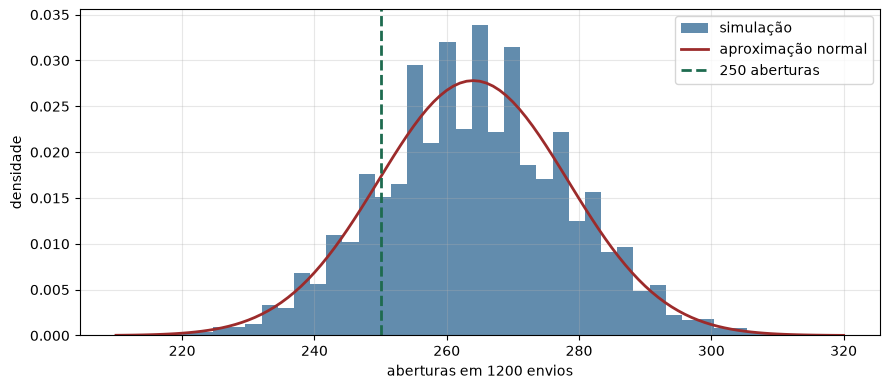

In [5]:
n, p = 1200, 0.22
media_teorica, dp_teorico = n * p, np.sqrt(n * p * (1 - p))

p_exata = stats.binom.cdf(250, n, p)
simulacao = rng.binomial(n, p, size=20_000)
p_empirica = (simulacao <= 250).mean()
# correção de continuidade: P(X <= 250) ≈ P(Z <= (250.5 - np)/sigma)
p_normal = stats.norm.cdf((250.5 - media_teorica) / dp_teorico)

painel("Binomial(1200, 0.22)",
       media=media_teorica, desvio_padrao=dp_teorico,
       P_ate_250_exata=p_exata, P_ate_250_simulada=p_empirica,
       P_ate_250_aprox_normal=p_normal)

print(f"np = {n*p:.0f} e n(1-p) = {n*(1-p):.0f} — ambos > 10, "
      "a aproximação normal é válida.")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(simulacao, bins=45, density=True, color=AZUL, alpha=0.7, label="simulação")
grade = np.arange(simulacao.min(), simulacao.max() + 1)
ax.plot(grade, stats.norm.pdf(grade, media_teorica, dp_teorico), color=VERMELHO,
        lw=2, label="aproximação normal")
ax.axvline(250, color=VERDE, lw=2, ls="--", label="250 aberturas")
ax.set_xlabel("aberturas em 1200 envios"); ax.set_ylabel("densidade")
ax.legend(); plt.tight_layout(); plt.show()

**Regra prática:** a aproximação normal da binomial vale quando $np \geq 10$ e
$n(1-p) \geq 10$. Aqui $np = 264$ — folgadíssimo. Com $p = 0{,}002$ e o mesmo
$n$, $np = 2{,}4$ e a aproximação certa passaria a ser a **Poisson**, não a normal.

A **correção de continuidade** (usar 250,5 em vez de 250) existe porque estamos
aproximando algo discreto por algo contínuo. Ela parece um detalhe e muda a
terceira casa decimal — mas em cauda extrema muda a ordem de grandeza.

---
## Exercício 3 🟡 — Poisson, superdispersão e o teste que denuncia

Você tem a contagem diária de chamados de suporte de um ano.

1. Gere os dados com o bloco fornecido (não olhe como foram gerados ainda).
2. Ajuste uma Poisson: estime $\lambda$ e compare **média** com **variância**.
3. Faça um teste qui-quadrado de aderência à Poisson.
4. Conclua: a Poisson serve?

> **Sinal-chave:** na Poisson, $\mathbb{E}[X] = \mathrm{Var}[X]$. Variância
> muito maior que a média chama-se **superdispersão**.

In [6]:
chamados = rng.negative_binomial(n=6, p=6 / (6 + 18), size=365)
print(chamados[:20])

[14 25 27 11 10  2 32 19 17 27 14 15 27 11  9 22 17 13 11 14]


In [7]:
# --- sua resposta ---

### Gabarito 3

Contagem diária de chamados
----------------------------------------------
media                                 17.9699
variancia                             77.2656
razao var media                        4.2997
n dias                               365.0000

Aderência à Poisson
----------------------------------------------
qui quadrado                          89.2321
graus de liberdade                    15.0000
p valor                                0.0000



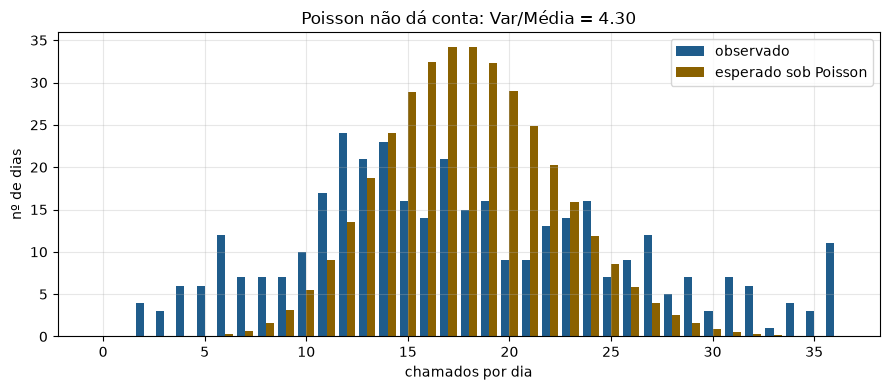

In [8]:
lam = chamados.mean()
razao = chamados.var(ddof=1) / lam

painel("Contagem diária de chamados",
       media=lam, variancia=chamados.var(ddof=1),
       razao_var_media=razao, n_dias=len(chamados))

# aderência: agrupa a cauda para manter esperados >= 5
limite = int(np.percentile(chamados, 97))
bordas = np.arange(0, limite + 2)
obs, _ = np.histogram(chamados, bins=np.append(bordas, np.inf))
prob = np.append(stats.poisson.pmf(bordas[:-1], lam),
                 1 - stats.poisson.cdf(bordas[-2], lam))
esp = prob * len(chamados)

mascara = esp >= 5
qui2 = (((obs[mascara] - esp[mascara]) ** 2) / esp[mascara]).sum()
gl = mascara.sum() - 1 - 1          # -1 pela restrição, -1 pelo lambda estimado
p_valor = 1 - stats.chi2.cdf(qui2, gl)

painel("Aderência à Poisson", qui_quadrado=qui2, graus_de_liberdade=float(gl),
       p_valor=p_valor)

fig, ax = plt.subplots(figsize=(9, 4))
centros = np.arange(len(obs))
ax.bar(centros - 0.2, obs, width=0.4, color=AZUL, label="observado")
ax.bar(centros + 0.2, esp, width=0.4, color=AMBAR, label="esperado sob Poisson")
ax.set_xlabel("chamados por dia"); ax.set_ylabel("nº de dias")
ax.set_title(f"Poisson não dá conta: Var/Média = {razao:.2f}")
ax.legend(); plt.tight_layout(); plt.show()

**Conclusão:** a razão variância/média é bem maior que 1 e o teste rejeita a
aderência. Os dados foram gerados de uma **binomial negativa** — o que na
prática significa que a taxa $\lambda$ **não é constante**: dias de deploy,
segundas-feiras e incidentes criam uma taxa que varia.

A binomial negativa é literalmente uma Poisson cuja taxa é ela mesma aleatória
(Gama). É o modelo padrão para contagens de negócio — e a razão pela qual
modelos de contagem em produção quase nunca são Poisson pura.

**Custo do erro:** usar Poisson aqui subestimaria a variância, e todo intervalo
de previsão sairia estreito demais — você dimensionaria a equipe de plantão
para um pico que acontece muito mais vezes do que o modelo diz.

---
## Exercício 4 🟡 — Exponencial e a falta de memória

Chamados chegam a uma taxa de 12 por hora.

1. Qual a probabilidade de esperar mais de 10 minutos pelo próximo?
2. Dado que **já esperei 10 minutos**, qual a probabilidade de esperar mais 10?
3. Verifique numericamente por simulação.
4. Repita o item 2 com uma **Weibull($k=2{,}5$)** de mesma média. O que muda?

In [9]:
# --- sua resposta ---

### Gabarito 4

In [10]:
taxa_hora = 12
escala = 1 / taxa_hora           # média em horas
dez_min = 10 / 60

p_mais_10 = stats.expon.sf(dez_min, scale=escala)
p_condicional = stats.expon.sf(2 * dez_min, scale=escala) / stats.expon.sf(dez_min, scale=escala)

amostra = rng.exponential(escala, 400_000)
p_cond_sim = (amostra > 2 * dez_min).sum() / (amostra > dez_min).sum()

painel("Exponencial (taxa 12/h)",
       P_espera_maior_10min=p_mais_10,
       P_mais_10min_dado_que_ja_esperei_10=p_condicional,
       mesma_coisa_por_simulacao=p_cond_sim)

# Weibull de MESMA média, mas com desgaste (k = 2.5)
k = 2.5
from math import gamma as fn_gama
lam_w = escala / fn_gama(1 + 1 / k)   # ajusta a escala para a média bater
w = stats.weibull_min(c=k, scale=lam_w)
painel("Weibull (k = 2.5, mesma média)",
       media=w.mean(), P_espera_maior_10min=w.sf(dez_min),
       P_mais_10min_dado_que_ja_esperei_10=w.sf(2 * dez_min) / w.sf(dez_min))

Exponencial (taxa 12/h)
----------------------------------------------
P espera maior 10min                   0.1353
P mais 10min dado que ja esperei 10       0.1353
mesma coisa por simulacao              0.1326

Weibull (k = 2.5, mesma média)
----------------------------------------------
media                                  0.0833
P espera maior 10min                   0.0151
P mais 10min dado que ja esperei 10       0.0000



**Falta de memória:** na exponencial, $P(X > 20 \mid X > 10) = P(X > 10)$ —
exatamente o mesmo número. O processo "esquece" o tempo já decorrido. Isso é
razoável para chegadas independentes (ninguém liga para o suporte *porque*
outra pessoa já ligou), e absurdo para desgaste.

Na Weibull com $k = 2{,}5$, a probabilidade condicional **cai**: quanto mais
tempo passou, mais provável que o evento aconteça em seguida. É a definição de
taxa de falha crescente — e a razão pela qual manutenção preditiva não usa
exponencial.

> A exponencial é a **única** distribuição contínua sem memória. Essa
> unicidade é o que a torna simultaneamente tão conveniente e tão perigosa.

---
## Exercício 5 🟡 — Cauda pesada: normal versus log-normal

Ticket médio de e-commerce. Você tem duas hipóteses de modelo.

1. Gere 5.000 tickets de uma log-normal com mediana R$ 180.
2. Ajuste uma normal e uma log-normal aos dados (método dos momentos ou MLE).
3. Compare a **probabilidade de um ticket acima de R$ 2.000** sob cada modelo,
   e com a frequência empírica.
4. Qual erro a normal comete e em que direção?

In [11]:
# --- sua resposta ---

### Gabarito 5

P(ticket > R$ 2000)
----------------------------------------------
empirica                               0.0020
sob normal                             0.0000
sob lognormal                          0.0020

A normal subestima a cauda em 645542363x.



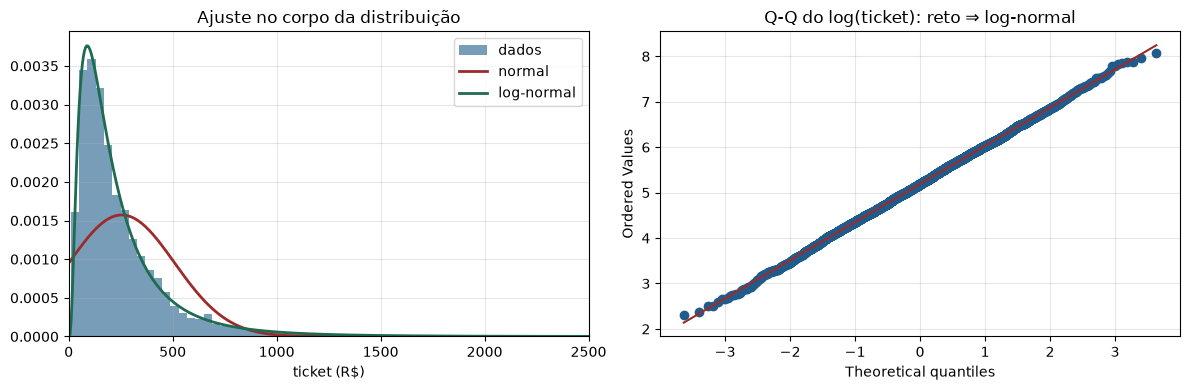

In [12]:
tickets = rng.lognormal(mean=np.log(180), sigma=0.85, size=5000)
CORTE = 2000

mu_n, sd_n = tickets.mean(), tickets.std(ddof=1)
shape, loc, scale = stats.lognorm.fit(tickets, floc=0)

p_emp = (tickets > CORTE).mean()
p_norm = stats.norm.sf(CORTE, mu_n, sd_n)
p_logn = stats.lognorm.sf(CORTE, shape, loc, scale)

painel(f"P(ticket > R$ {CORTE})",
       empirica=p_emp, sob_normal=p_norm, sob_lognormal=p_logn)
print(f"A normal subestima a cauda em {p_emp / max(p_norm, 1e-12):.0f}x.\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
grade = np.linspace(1, tickets.max(), 600)
axes[0].hist(tickets, bins=80, density=True, color=AZUL, alpha=0.6, label="dados")
axes[0].plot(grade, stats.norm.pdf(grade, mu_n, sd_n), color=VERMELHO, lw=2, label="normal")
axes[0].plot(grade, stats.lognorm.pdf(grade, shape, loc, scale), color=VERDE, lw=2,
             label="log-normal")
axes[0].set_xlim(0, 2500); axes[0].set_xlabel("ticket (R$)"); axes[0].legend()
axes[0].set_title("Ajuste no corpo da distribuição")

stats.probplot(np.log(tickets), dist="norm", plot=axes[1])
axes[1].set_title("Q-Q do log(ticket): reto ⇒ log-normal")
axes[1].get_lines()[0].set_color(AZUL); axes[1].get_lines()[1].set_color(VERMELHO)
plt.tight_layout(); plt.show()

**O erro da normal:** ela **subestima a cauda direita** em ordens de grandeza,
e ainda atribui probabilidade positiva a tickets **negativos** — algo
impossível no domínio.

Consequências concretas de usar normal aqui:

- previsão de receita que ignora os pedidos grandes, que são justamente onde a
  margem está;
- limites de detecção de fraude calibrados como "média + 3 desvios", que
  marcariam clientes legítimos às centenas;
- intervalos de previsão que incluem valores impossíveis.

**Diagnóstico rápido:** se o Q-Q plot do **log** da variável for reto, a
variável é log-normal. Grandezas que resultam de efeitos **multiplicativos**
(preço × quantidade × conversão) são log-normais por construção — o TLC atua
na soma dos logs.

---
## Exercício 6 🔴 — TLC: onde ele funciona e onde ele falha

1. Mostre o TLC em ação: médias amostrais de uma distribuição **muito**
   assimétrica convergem para a normal conforme $n$ cresce ($n = 2, 5, 30, 200$).
2. Agora repita com uma **Cauchy**. O que acontece? Por quê?

In [13]:
# --- sua resposta ---

### Gabarito 6

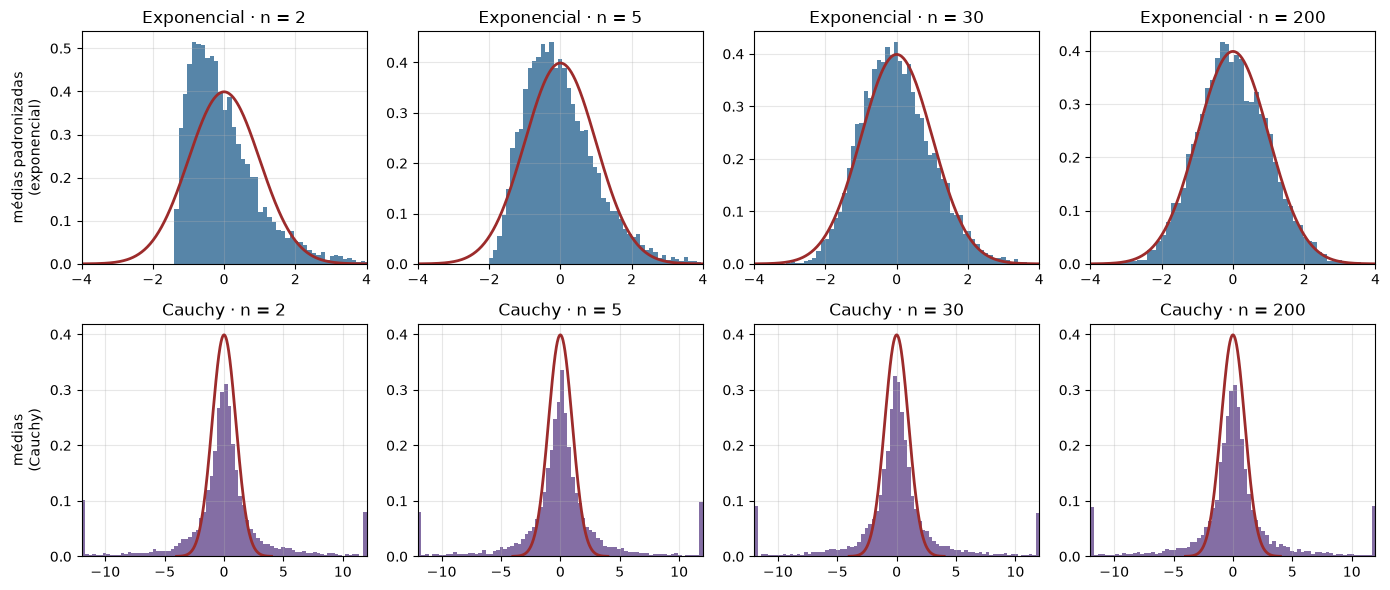

dispersão das médias da Cauchy, por n:
  n =   2  IQR das médias = 2.031
  n =   5  IQR das médias = 2.009
  n =  30  IQR das médias = 2.045
  n = 200  IQR das médias = 2.002


In [14]:
TAMANHOS = [2, 5, 30, 200]
REPETICOES = 8000

fig, axes = plt.subplots(2, len(TAMANHOS), figsize=(14, 6))
for j, n_amostra in enumerate(TAMANHOS):
    medias_exp = rng.exponential(1.0, (REPETICOES, n_amostra)).mean(axis=1)
    z = (medias_exp - medias_exp.mean()) / medias_exp.std(ddof=1)
    axes[0, j].hist(z, bins=60, density=True, color=AZUL, alpha=0.75)
    g = np.linspace(-4, 4, 300)
    axes[0, j].plot(g, stats.norm.pdf(g), color=VERMELHO, lw=2)
    axes[0, j].set_xlim(-4, 4)
    axes[0, j].set_title(f"Exponencial · n = {n_amostra}")

    medias_cau = stats.cauchy.rvs(size=(REPETICOES, n_amostra),
                                  random_state=rng.integers(1e9)).mean(axis=1)
    axes[1, j].hist(np.clip(medias_cau, -12, 12), bins=80, density=True,
                    color=ROXO, alpha=0.75)
    axes[1, j].plot(g, stats.norm.pdf(g), color=VERMELHO, lw=2)
    axes[1, j].set_xlim(-12, 12)
    axes[1, j].set_title(f"Cauchy · n = {n_amostra}")
axes[0, 0].set_ylabel("médias padronizadas\n(exponencial)")
axes[1, 0].set_ylabel("médias\n(Cauchy)")
plt.tight_layout(); plt.show()

print("dispersão das médias da Cauchy, por n:")
for n_amostra in TAMANHOS:
    m = stats.cauchy.rvs(size=(4000, n_amostra), random_state=rng.integers(1e9)).mean(axis=1)
    print(f"  n = {n_amostra:>3d}  IQR das médias = {np.subtract(*np.percentile(m, [75, 25])):.3f}")

**Linha de cima:** o TLC funciona. Já em $n = 30$ a média padronizada de uma
exponencial — assimetria 2 — é praticamente indistinguível de uma normal.

**Linha de baixo:** a Cauchy **não converge**. A média de $n$ Cauchys tem
exatamente a mesma distribuição de **uma única** Cauchy: o IQR não encolhe com
$n$. Coletar mais dados não melhora a estimativa em nada.

**Por quê:** o TLC exige **variância finita**. A Cauchy não tem média nem
variância definidas (a integral diverge). A hipótese não é decorativa.

**Onde isso morde na prática:** retornos financeiros, tamanhos de arquivos,
audiência de conteúdo e valores de sinistro têm caudas quase tão pesadas que a
variância amostral **não estabiliza**. Nesses domínios, "n grande garante
normalidade" é falso, e o intervalo de confiança construído sobre o TLC mente.

---
## Exercício 7 🔴 — Desafio: escolher a distribuição a partir dos dados

Escreva uma função `sugere_distribuicao(x)` que:

1. detecte se os dados são **discretos** ou **contínuos**;
2. teste um conjunto de candidatas plausíveis;
3. ordene por **AIC** (não só por log-verossimilhança — o AIC penaliza
   parâmetros a mais);
4. devolva uma tabela e plote o melhor ajuste sobre o histograma.

Teste com os `tickets` do Exercício 5 e com os `chamados` do Exercício 3.

In [15]:
# --- sua resposta ---

### Gabarito 7

dados CONTÍNUOS · n = 5000
distribuicao  k   loglik     AIC  delta_AIC
   lognormal  2 -32176.1 64356.2        0.0
        gama  2 -32435.0 64873.9      517.8
     weibull  2 -32563.5 65131.1      774.9
 exponencial  1 -32708.2 65418.3     1062.1
      normal  2 -34777.0 69557.9     5201.8


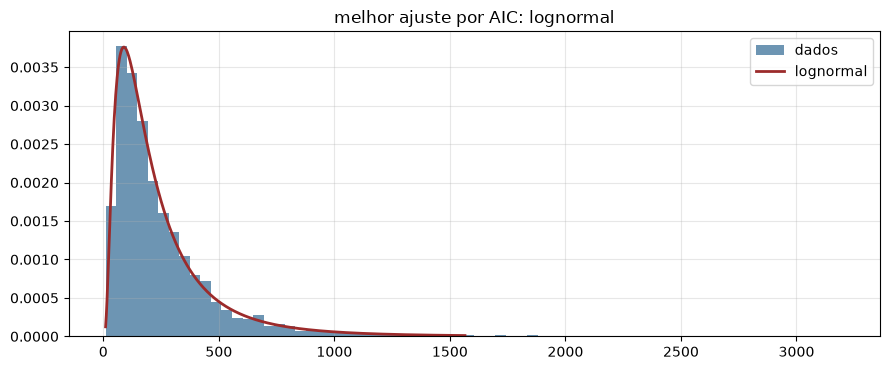

dados DISCRETOS · n = 365
     distribuicao  k  loglik    AIC  delta_AIC
binomial negativa  2 -1290.9 2585.8        0.0
          poisson  1 -1615.1 3232.2      646.4


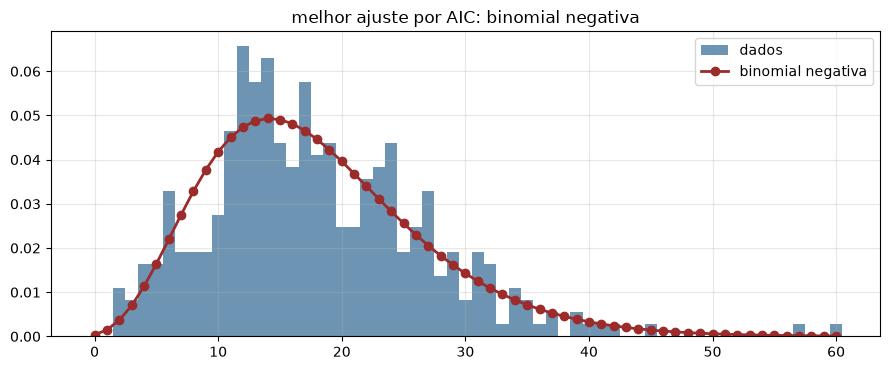

In [16]:
CONTINUAS = {"normal": stats.norm, "lognormal": stats.lognorm, "gama": stats.gamma,
             "exponencial": stats.expon, "weibull": stats.weibull_min}


def sugere_distribuicao(x, plotar=True):
    x = np.asarray(x, dtype=float)
    discreto = np.allclose(x, np.round(x)) and x.min() >= 0

    linhas = []
    if discreto:
        lam = x.mean()
        ll_pois = stats.poisson.logpmf(x, lam).sum()
        linhas.append(("poisson", 1, ll_pois, 2 * 1 - 2 * ll_pois, (lam,)))

        media, var = x.mean(), x.var(ddof=1)
        if var > media:                       # binomial negativa só faz sentido aqui
            r = media ** 2 / (var - media)
            prob = r / (r + media)
            ll_nb = stats.nbinom.logpmf(x, r, prob).sum()
            linhas.append(("binomial negativa", 2, ll_nb, 2 * 2 - 2 * ll_nb, (r, prob)))
    else:
        positivos = x.min() > 0
        for nome, dist in CONTINUAS.items():
            if nome != "normal" and not positivos:
                continue
            try:
                par = dist.fit(x, floc=0) if nome != "normal" else dist.fit(x)
            except Exception:
                continue
            ll = dist.logpdf(x, *par).sum()
            k = len([p for p in par if p != 0])
            linhas.append((nome, k, ll, 2 * k - 2 * ll, par))

    tabela = (pd.DataFrame(linhas, columns=["distribuicao", "k", "loglik", "AIC", "params"])
              .sort_values("AIC").reset_index(drop=True))
    tabela["delta_AIC"] = tabela["AIC"] - tabela["AIC"].min()
    print(f"dados {'DISCRETOS' if discreto else 'CONTÍNUOS'} · n = {len(x)}")
    print(tabela[["distribuicao", "k", "loglik", "AIC", "delta_AIC"]].round(1).to_string(index=False))

    if plotar:
        melhor = tabela.iloc[0]
        fig, ax = plt.subplots(figsize=(9, 3.8))
        if discreto:
            vals = np.arange(0, int(x.max()) + 1)
            ax.hist(x, bins=np.append(vals, vals[-1] + 1) - 0.5, density=True,
                    color=AZUL, alpha=0.65, label="dados")
            pmf = (stats.poisson.pmf(vals, *melhor["params"])
                   if melhor["distribuicao"] == "poisson"
                   else stats.nbinom.pmf(vals, *melhor["params"]))
            ax.plot(vals, pmf, "o-", color=VERMELHO, lw=2, label=melhor["distribuicao"])
        else:
            ax.hist(x, bins=70, density=True, color=AZUL, alpha=0.65, label="dados")
            g = np.linspace(x.min(), np.percentile(x, 99.5), 500)
            ax.plot(g, CONTINUAS[melhor["distribuicao"]].pdf(g, *melhor["params"]),
                    color=VERMELHO, lw=2, label=melhor["distribuicao"])
        ax.set_title(f"melhor ajuste por AIC: {melhor['distribuicao']}")
        ax.legend(); plt.tight_layout(); plt.show()
    return tabela


_ = sugere_distribuicao(tickets)
_ = sugere_distribuicao(chamados)

**Por que AIC e não log-verossimilhança:** acrescentar parâmetros **sempre**
aumenta a verossimilhança. O AIC $= 2k - 2\ell$ cobra 2 pontos por parâmetro,
então só vale a pena complicar o modelo se o ganho em ajuste superar o preço.

**Como ler o $\Delta$AIC:** diferença abaixo de 2 significa que os modelos são
praticamente equivalentes — escolha o mais simples ou o mais interpretável.
Acima de 10, o modelo pior está descartado.

**A ressalva que fecha o módulo:** AIC compara **entre as candidatas que você
ofereceu**. Se a verdadeira distribuição não está na lista, a função devolve
com toda a confiança a menos ruim de um conjunto errado. Por isso o
diagnóstico gráfico e o **conhecimento do mecanismo gerador** vêm antes do
critério numérico, nunca depois.

---
## Fechamento

- **Identifique o mecanismo, não a forma.** Contagem em intervalo → Poisson;
  tempo entre eventos → Exponencial; produto de efeitos → Log-normal.
- **Var/Média ≫ 1 em contagens** é superdispersão: troque Poisson por binomial
  negativa.
- **Falta de memória é uma hipótese forte**, não um detalhe da exponencial.
- **TLC exige variância finita.** Em domínios de cauda pesada, ele não te salva.
- **Compare modelos por AIC**, mas escolha as candidatas com a cabeça.

→ Próximo módulo: **Inferência e Estimação** — como ir da amostra para os
parâmetros que você acabou de assumir que existem.